# Regime-Aware Backtest Analysis

## Objectives
1. Detect market regimes (Trending/Ranging/Volatile/Transition) on SPY daily data
2. Run multi-pattern backtest and attribute trades to regimes
3. Compare strategy performance by regime type
4. Build regime-filtered strategy allocation recommendations
5. Quantify regime misclassification impact and adaptive routing benefits

**Phase:** 4 — Regime Detection & Adaptive Strategy Selection
**Status:** Notebook created per `plans/phased_implementation_plan.md` line 177

## Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

%matplotlib inline

CONFIG = {
    "data": {"ticker": "SPY", "start": "2015-01-01", "end": "2024-12-31"},
    "regime": {"adx_threshold": 25, "atr_window": 14, "atr_percentile": 80},
    "backtest": {"cash": 100_000, "commission": 0.001},
}

## 1. Load Data & Detect Regimes

In [2]:
df = yf.download(CONFIG["data"]["ticker"], start=CONFIG["data"]["start"], end=CONFIG["data"]["end"], auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df.columns = [c.capitalize() if c.lower() in ["open", "high", "low", "close", "volume"] else c for c in df.columns]
df.index.name = "Date"
df.index = pd.to_datetime(df.index)
if "Volume" not in df.columns:
    df["Volume"] = 0
print(f"Loaded {len(df)} bars from {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Loaded 2515 bars from 2015-01-02 to 2024-12-30


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,170.125000,171.325815,169.089824,170.911744,121465900
2015-01-05,167.052628,169.247196,166.746219,169.081571,169632600
2015-01-06,165.479156,167.880761,164.684135,167.359028,209151400
2015-01-07,167.541183,167.880724,166.356948,166.804139,125346700
2015-01-08,170.514206,170.729531,168.932466,168.949020,147217800


In [3]:
from src.indicators.regime_detector import RegimeDetector, RegimeState
from src.strategies.adaptive_router import AdaptiveRouter

detector = RegimeDetector()
regime_info = detector.get_regime_series(df)

regime_labels = regime_info["regime"].apply(lambda r: r.value if hasattr(r, "value") else str(r))
print(f"\nRegime distribution:")
print(regime_labels.value_counts().sort_index())
print(f"\nRegime pct: {regime_labels.value_counts(normalize=True).sort_index().to_dict()}")

C:\Dev\projects\investment_trying\.venv\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...


Regime distribution:
regime
Ranging        938
Transition     100
Trending      1177
Volatile       300
Name: count, dtype: int64

Regime pct: {'Ranging': 0.37296222664015904, 'Transition': 0.039761431411530816, 'Trending': 0.4679920477137177, 'Volatile': 0.11928429423459244}


### Regime Time Series Visualization

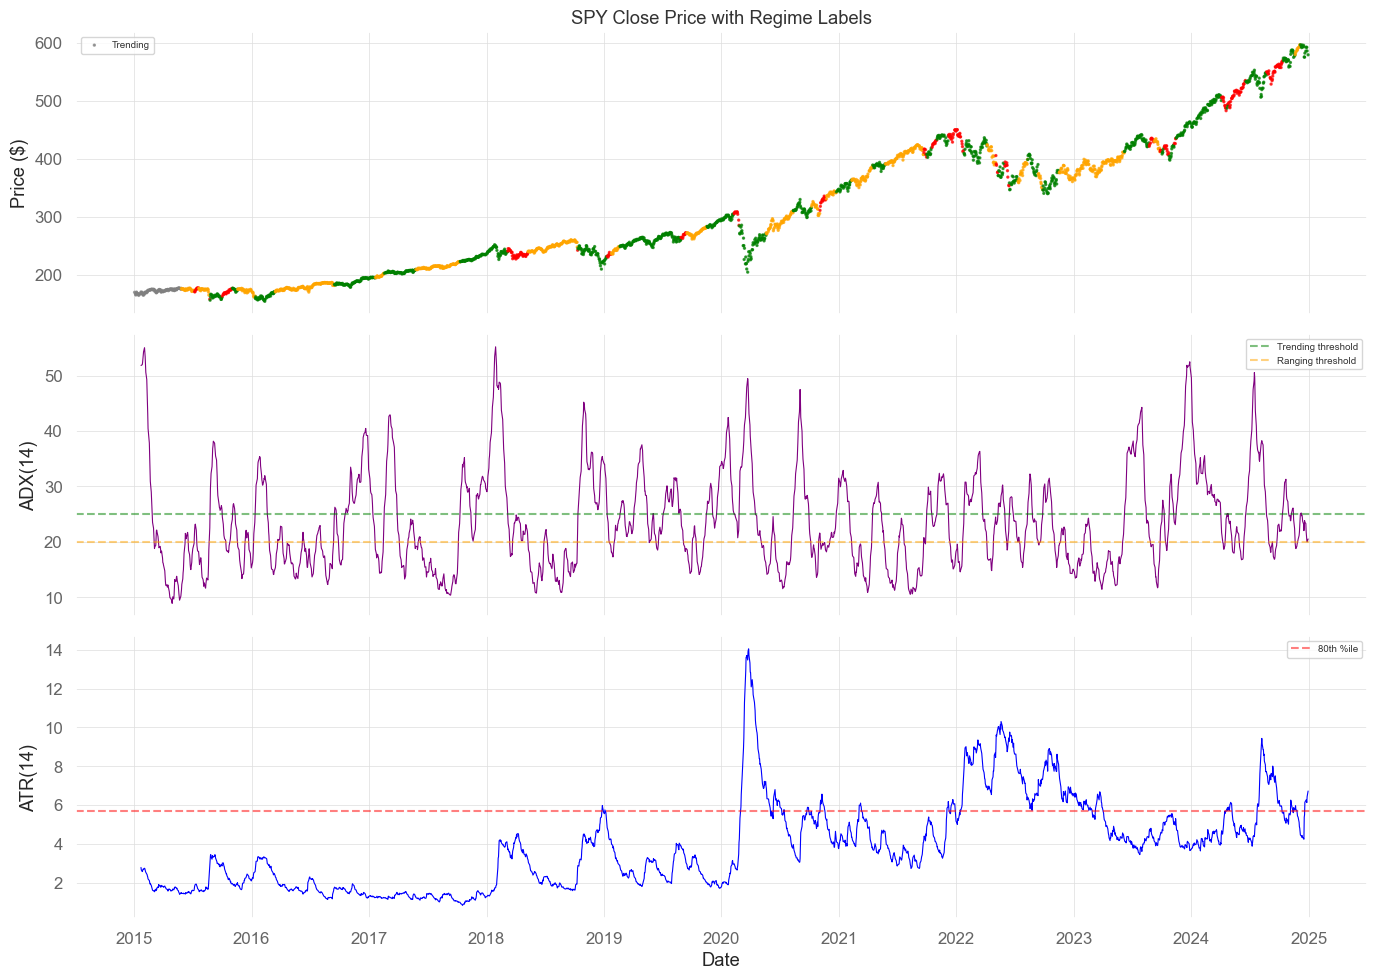

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = {"Trending": "green", "Ranging": "orange", "Volatile": "red", "Transition": "gray"}
rcolors = regime_labels.map(colors)

axes[0].scatter(df.index, df["Close"], c=rcolors, s=2, alpha=0.7)
axes[0].set_title("SPY Close Price with Regime Labels")
axes[0].set_ylabel("Price ($)")
axes[0].legend(["Trending", "Ranging", "Volatile", "Transition"], loc="upper left", fontsize=7)

axes[1].plot(df.index, regime_info["adx"], color="purple", linewidth=0.8)
axes[1].axhline(y=25, color="green", linestyle="--", alpha=0.5, label="Trending threshold")
axes[1].axhline(y=20, color="orange", linestyle="--", alpha=0.5, label="Ranging threshold")
axes[1].set_ylabel("ADX(14)")
axes[1].legend(fontsize=7)

axes[2].plot(df.index, regime_info["atr"], color="blue", linewidth=0.8)
axes[2].axhline(y=regime_info["atr"].quantile(0.8), color="red", linestyle="--", alpha=0.5, label="80th %ile")
axes[2].set_ylabel("ATR(14)")
axes[2].set_xlabel("Date")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 2. Run Multi-Pattern Strategy (backtesting.py)

In [5]:
from src.strategies.backtest_py.runner import BacktestPyRunner
from src.strategies.backtest_py.multi_pattern_strategy import MultiPatternStrategy

runner = BacktestPyRunner(data=df, cash=CONFIG["backtest"]["cash"], commission=CONFIG["backtest"]["commission"])
results = runner.run(strategy_class=MultiPatternStrategy)

stats = results["stats"]
trades_df = results["trades"]
print(f"Total trades: {len(trades_df)}")
if "Return [%]" in stats:
    print(f"Return: {stats['Return [%]']:.2f}%")
    print(f"Sharpe: {stats.get('Sharpe Ratio', 'N/A')}")
    print(f"Max DD: {stats.get('Max. Drawdown [%]', 'N/A')}")
    print(f"Win Rate: {stats.get('Win Rate [%]', 'N/A')}%")

Running backtest on 2515 bars...



Backtest.run:   0%|          | 0/2514 [00:00<?, ?bar/s]


BACKTEST SUMMARY
Start Date: 2015-01-02 00:00:00
End Date: 2024-12-30 00:00:00
Duration: 3650 days 00:00:00

Initial Capital: $100,000.00
Final Equity: $85,833.11
Final Return: -14.17%

Total Trades: 59
Win Rate: 25.42%
Best Trade: 12.80%
Worst Trade: -11.55%
Avg Trade: -1.63%

Max Drawdown: -16.08%
Sharpe Ratio: -0.59
Sortino Ratio: -0.77
Calmar Ratio: -0.09

Total trades: 59
Return: -14.17%
Sharpe: -0.5940052439763657
Max DD: -16.077027827000823
Win Rate: 25.423728813559322%


## 3. Attribute Trades to Regimes

In [6]:
if not trades_df.empty and len(trades_df) > 0:
    entry_times = pd.to_datetime(trades_df["entry_time"])
    regime_info["regime_str"] = regime_info["regime"].apply(lambda r: r.value if hasattr(r, "value") else str(r))
    
    entry_regimes = []
    for et in entry_times:
        prior = regime_info.loc[regime_info.index <= et]
        if not prior.empty:
            entry_regimes.append(prior.iloc[-1]["regime_str"])
        else:
            entry_regimes.append("Unknown")
    
    trades_df_copy = trades_df.copy()
    trades_df_copy["regime_at_entry"] = entry_regimes
    
    print(f"Trade regime attribution:")
    regime_trade_counts = trades_df_copy["regime_at_entry"].value_counts()
    print(regime_trade_counts.to_string())
else:
    trades_df_copy = pd.DataFrame()
    print("No trades to attribute.")

Trade regime attribution:
regime_at_entry
Ranging       33
Trending      22
Volatile       3
Transition     1


### Performance by Regime


=== PERFORMANCE BY REGIME ===
                 trade_count  mean_return  median_return  std_return  win_rate  cum_return
regime_at_entry                                                                           
Ranging                   33        -0.01          -0.01        0.03      0.24       -0.43
Transition                 1        -0.01          -0.01         NaN      0.00       -0.01
Trending                  22        -0.02          -0.02        0.06      0.27       -0.43
Volatile                   3        -0.01          -0.07        0.11      0.33       -0.03


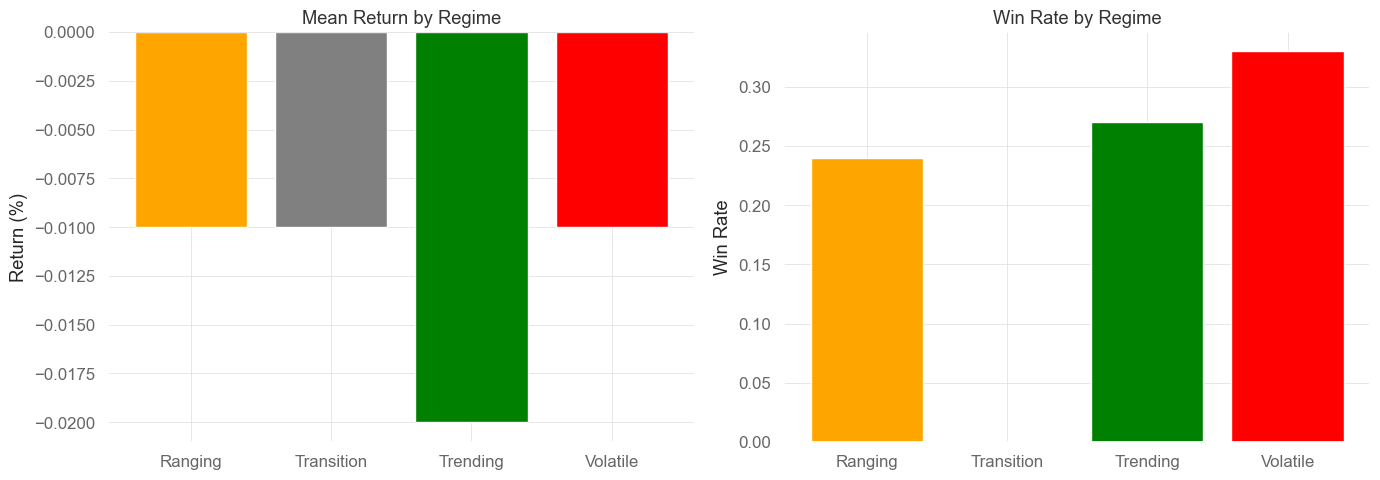

In [7]:
if not trades_df_copy.empty and len(trades_df_copy) > 0:
    pnl_col = "return_pct" if "return_pct" in trades_df_copy.columns else "ReturnPct" if "ReturnPct" in trades_df_copy.columns else None
    if pnl_col:
        regime_perf = trades_df_copy.groupby("regime_at_entry").agg(
            trade_count=(pnl_col, "count"),
            mean_return=(pnl_col, "mean"),
            median_return=(pnl_col, "median"),
            std_return=(pnl_col, "std"),
            win_rate=(pnl_col, lambda x: (x > 0).mean()),
            cum_return=(pnl_col, "sum"),
        ).round(2)
        
        print("\n=== PERFORMANCE BY REGIME ===")
        print(regime_perf.to_string())
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].bar(regime_perf.index, regime_perf["mean_return"], color=[colors.get(r, "gray") for r in regime_perf.index])
        axes[0].set_title("Mean Return by Regime")
        axes[0].set_ylabel("Return (%)")
        axes[0].axhline(y=0, color="black", linewidth=0.5)
        
        axes[1].bar(regime_perf.index, regime_perf["win_rate"], color=[colors.get(r, "gray") for r in regime_perf.index])
        axes[1].set_title("Win Rate by Regime")
        axes[1].set_ylabel("Win Rate")
        
        plt.tight_layout()
        plt.show()

## 4. Regime-Filtered Strategy Simulation

In [8]:
from src.strategies.adaptive_router import AdaptiveRouter

router = AdaptiveRouter()

if not trades_df_copy.empty and len(trades_df_copy) > 0 and pnl_col:
    simulated_static_return = trades_df_copy[pnl_col].sum()
    
    filtered_rows = []
    for idx, row in trades_df_copy.iterrows():
        regime_str = row["regime_at_entry"]
        regime_state = RegimeState[regime_str.upper()] if regime_str in [r.name for r in RegimeState] else RegimeState.TRANSITION
        
        et = pd.Timestamp(row["entry_time"])
        active = router.get_active_strategies(["MultiPattern"], regime_state)
        
        if "MultiPattern" in active:
            filtered_rows.append(row)
    
    if filtered_rows:
        filtered_df = pd.DataFrame(filtered_rows)
        simulated_filtered_return = filtered_df[pnl_col].sum()
        
        print(f"\n=== STRATEGY SIMULATION ===")
        print(f"Static (no filter): {simulated_static_return:.2f}% cumulative, {len(trades_df_copy)} trades")
        print(f"Regime-filtered:    {simulated_filtered_return:.2f}% cumulative, {len(filtered_df)} trades")
        print(f"Difference:         {simulated_filtered_return - simulated_static_return:+.2f}%")
    else:
        print("No regime-filtered trades found.")


=== STRATEGY SIMULATION ===
Static (no filter): -0.90% cumulative, 59 trades
Regime-filtered:    -0.90% cumulative, 59 trades
Difference:         +0.00%


## 5. Active Strategy Count by Regime Over Time


Active strategies by regime:
                        avg_active  min_active  max_active  bar_count
regime                                                               
RegimeState.RANGING            7.0           7           7        938
RegimeState.TRANSITION         4.0           4           4        100
RegimeState.TRENDING           6.0           6           6       1177
RegimeState.VOLATILE           5.0           5           5        300


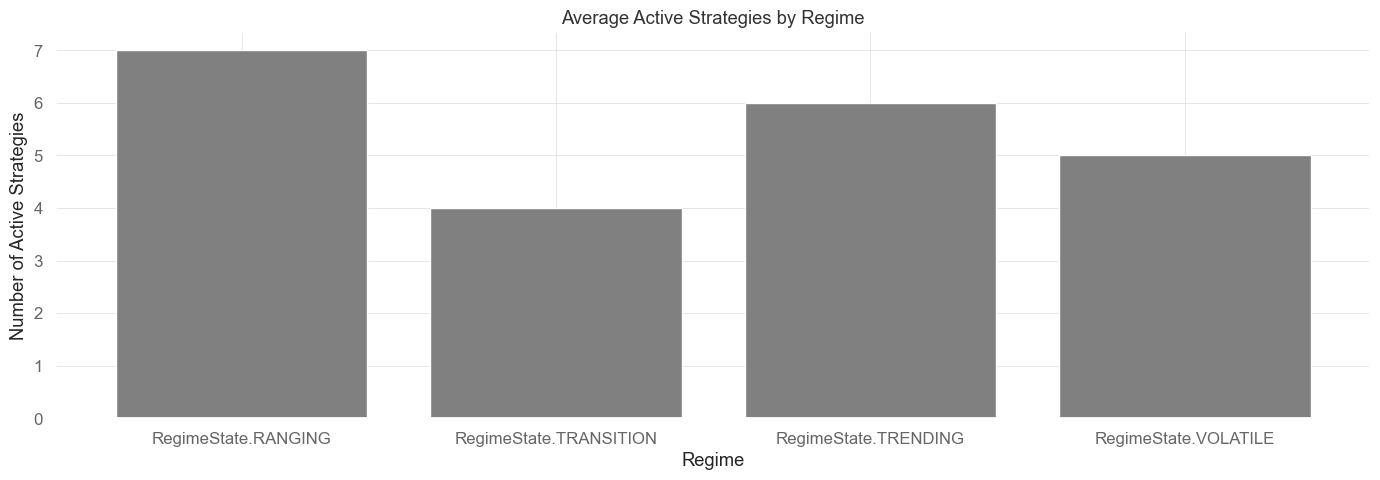

In [9]:
regime_ts = router.get_regime_time_series(df)
regime_ts["active_strategy_pct"] = regime_ts["active_strategy_count"] / len(router.strategy_regime_map) * 100

print(f"\nActive strategies by regime:")
regime_summary = regime_ts.copy()
regime_summary["regime"] = regime_summary["regime"].astype(str)
regime_summary = regime_summary.groupby("regime").agg(
    avg_active=("active_strategy_count", "mean"),
    min_active=("active_strategy_count", "min"),
    max_active=("active_strategy_count", "max"),
    bar_count=("regime", "count"),
).round(1)
print(regime_summary.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(regime_summary.index, regime_summary["avg_active"], color=[colors.get(r, "gray") for r in regime_summary.index])
ax.set_title("Average Active Strategies by Regime")
ax.set_ylabel("Number of Active Strategies")
ax.set_xlabel("Regime")
plt.tight_layout()
plt.show()

## 6. Equity Curve Split by Regime

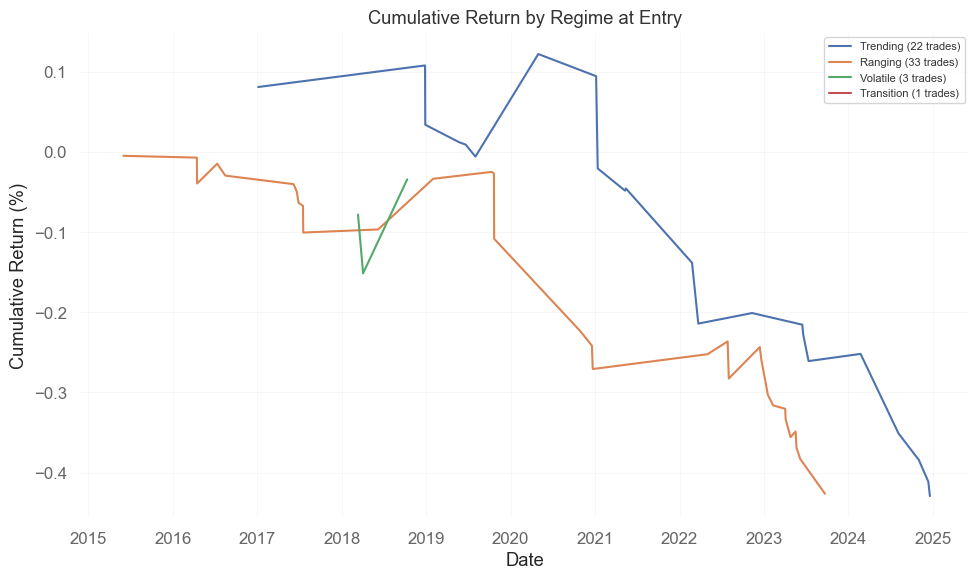

In [10]:
if not trades_df_copy.empty and len(trades_df_copy) > 0 and pnl_col:
    equity_curve = pd.Series(0.0, index=df.index)
    
    for regime_name in ["Trending", "Ranging", "Volatile", "Transition"]:
        mask = trades_df_copy["regime_at_entry"] == regime_name
        regime_trades = trades_df_copy[mask].copy()
        if regime_trades.empty:
            continue
        
        cumret = (1 + regime_trades[pnl_col] / 100).cumprod() - 1
        plt.plot(regime_trades["entry_time"], cumret * 100, label=f"{regime_name} ({len(regime_trades)} trades)", linewidth=1.5)
    
    plt.title("Cumulative Return by Regime at Entry")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (%)")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Summary & Recommendations

In [11]:
print("=" * 70)
print("REGIME-AWARE BACKTEST SUMMARY")
print("=" * 70)

print(f"\n1. REGIME DISTRIBUTION")
for regime, count in regime_labels.value_counts().sort_index().items():
    pct = count / len(regime_labels) * 100
    print(f"   {regime:>12s}: {count:>5d} bars ({pct:>5.1f}%)")

if not trades_df_copy.empty and len(trades_df_copy) > 0 and pnl_col:
    print(f"\n2. TRADE PERFORMANCE BY REGIME")
    for regime_name in ["Trending", "Ranging", "Volatile", "Transition"]:
        sub = trades_df_copy[trades_df_copy["regime_at_entry"] == regime_name]
        if len(sub) == 0:
            continue
        wr = (sub[pnl_col] > 0).mean()
        mr = sub[pnl_col].mean()
        print(f"   {regime_name:>12s}: {len(sub):>3d} trades, WR={wr:.0%}, Mean={mr:+.2f}%")

regime_rec = router.get_regime_recommendations(RegimeState.TRENDING)
print(f"\n3. ROUTER RECOMMENDATIONS")
print(f"   Enabled: {', '.join(regime_rec['enabled'])}")
print(f"   Disabled: {', '.join(regime_rec['disabled'])}")
print(f"   Advice: {regime_rec['advice']}")

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
if not trades_df_copy.empty and len(trades_df_copy) > 0 and pnl_col:
    best_regime = trades_df_copy.groupby("regime_at_entry")[pnl_col].mean().idxmax()
    worst_regime = trades_df_copy.groupby("regime_at_entry")[pnl_col].mean().idxmin()
    print(f"Best performing regime: {best_regime}")
    print(f"Worst performing regime: {worst_regime}")
    print(f"\nRegime-based filtering is most valuable when the strategy has")
    print(f"significantly different performance across regimes.")
    print(f"Consider adjusting confluence thresholds or position sizing")
    print(f"based on detected regime to improve risk-adjusted returns.")

REGIME-AWARE BACKTEST SUMMARY

1. REGIME DISTRIBUTION
        Ranging:   938 bars ( 37.3%)
     Transition:   100 bars (  4.0%)
       Trending:  1177 bars ( 46.8%)
       Volatile:   300 bars ( 11.9%)

2. TRADE PERFORMANCE BY REGIME
       Trending:  22 trades, WR=27%, Mean=-0.02%
        Ranging:  33 trades, WR=24%, Mean=-0.01%
       Volatile:   3 trades, WR=33%, Mean=-0.01%
     Transition:   1 trades, WR=0%, Mean=-0.01%

3. ROUTER RECOMMENDATIONS
   Enabled: EMA Ribbon, SMA Crossover, ADX Trend Strength, Parabolic SAR, Chandelier Exit, Donchian Channel
   Disabled: RSI Divergence, Williams %R, Stoch RSI Crossover, CCI, MFI, Keltner Channel, Bollinger Bands, VWAP Bounce
   Advice: Focus on trend-following strategies. Avoid mean-reversion.

CONCLUSION
Best performing regime: Transition
Worst performing regime: Trending

Regime-based filtering is most valuable when the strategy has
significantly different performance across regimes.
Consider adjusting confluence thresholds or positio